# Projeto: Análise e Predição de Culturas Agrícolas

Este projeto analisa uma base de dados com informações de condições de solo
e temperatura relacionadas a diversos tipos de culturas agrícolas.

O objetivo é realizar uma análise exploratória, encontrar perfis ideais de
plantio e construir 5 modelos preditivos utilizando boas práticas de Machine
Learning (incluindo tratamento de duplicatas, análise de outliers, codificação
de variáveis, escalonamento e separação rigorosa em Treino / Validação / Teste).

**Variáveis do dataset:**
- N: quantidade de nitrogênio no solo
- P: quantidade de fósforo no solo
- K: quantidade de potássio no solo
- temperature: temperatura média da região em graus Celsius
- humidity: umidade média do ar na região
- ph: pH do solo
- rainfall: precipitação em milímetros
- label: tipo de cultura plantada nas condições daquela linha

In [64]:
# =============================================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100


# 2. Carregamento e Análise Exploratória Inicial

O primeiro passo de qualquer projeto de Machine Learning é conhecer os dados.
Vamos verificar dimensões, tipos de variáveis, valores nulos e as primeiras
linhas do dataset para entender com o que estamos trabalhando.

In [65]:
# =============================================================================
# 2. CARREGAMENTO E ANÁLISE EXPLORATÓRIA INICIAL
# =============================================================================
df = pd.read_csv('produtos_agricolas.csv')

print("=" * 60)
print("ANÁLISE EXPLORATÓRIA INICIAL")
print("=" * 60)

print(f"\n--- Dimensões do Dataset ---")
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

print("\n--- Primeiras Linhas ---")
print(df.head())

print("\n--- Informações Gerais ---")
df.info()

print("\n--- Estatísticas Descritivas ---")
print(df.describe())

print("\n--- Valores Nulos por Coluna ---")
print(df.isnull().sum())

ANÁLISE EXPLORATÓRIA INICIAL

--- Dimensões do Dataset ---
Linhas: 2200, Colunas: 8

--- Primeiras Linhas ---
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 n

# 3. Limpeza de Dados: Duplicatas e Outliers

### 3.1 Dados Duplicados
Dados duplicados podem contaminar os conjuntos de treino e teste, gerando
vazamento de dados (data leakage) e métricas artificialmente infladas.
Verificamos e removemos quaisquer linhas duplicadas.

### 3.2 Outliers
Avaliamos os outliers via boxplot. Em dados biológicos e agrícolas, valores
extremos (como altíssimo potássio) não são necessariamente erros de leitura —
eles representam a assinatura nutricional real de certas culturas (ex: uvas).

**Decisão estratégica:** optamos estrategicamente por não remover os outliers, preservando a assinatura química das plantas.


LIMPEZA DE DADOS

Número de dados duplicados encontrados: 0
Nenhuma duplicata encontrada. Dataset íntegro.


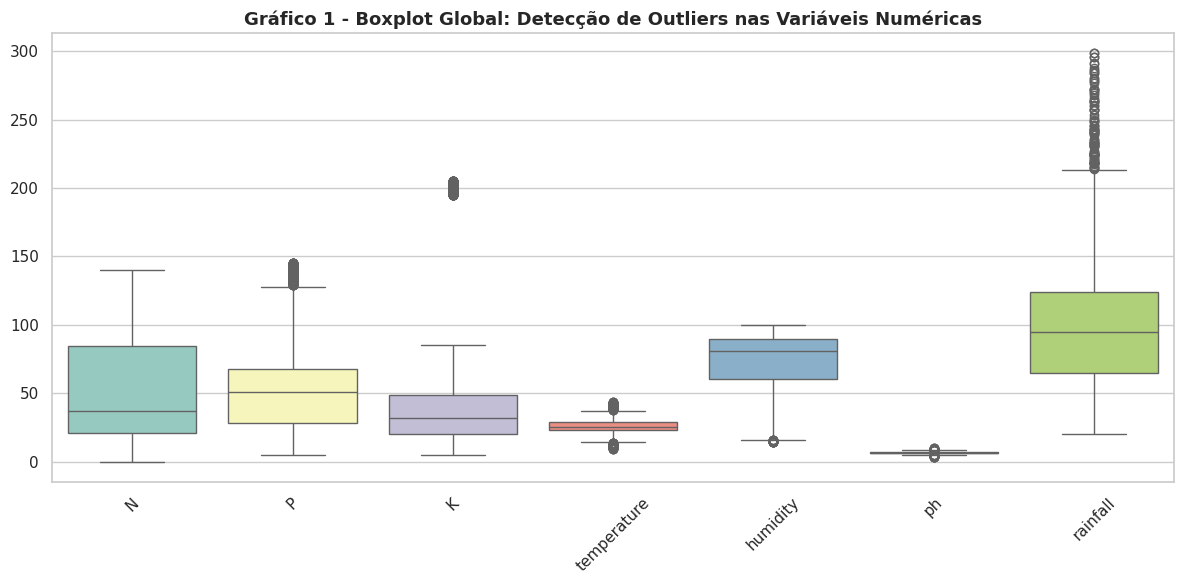


Análise de outliers concluída via boxplot.
Decisão: outliers preservados — valores extremos refletem
características reais de culturas específicas (ex: culturas do dataset,
com valores muito elevados de K


In [66]:
# =============================================================================
# 3. LIMPEZA DE DADOS: DUPLICATAS E OUTLIERS
# =============================================================================
print("\n" + "=" * 60)
print("LIMPEZA DE DADOS")
print("=" * 60)

# --- Verificar e remover dados duplicados ---
duplicates = df.duplicated().sum()
print(f"\nNúmero de dados duplicados encontrados: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicatas removidas. Novo shape: {df.shape}")
else:
    print("Nenhuma duplicata encontrada. Dataset íntegro.")

# --- Gráfico 1: Boxplot Global para Detecção de Outliers ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop('label', axis=1), palette='Set3')
plt.title("Gráfico 1 - Boxplot Global: Detecção de Outliers nas Variáveis Numéricas",
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nAnálise de outliers concluída via boxplot.")
print("Decisão: outliers preservados — valores extremos refletem")
print("características reais de culturas específicas (ex: culturas do dataset,")
print("com valores muito elevados de K")

# 4. Análise Descritiva Visual

Abaixo geramos gráficos para entender as distribuições, correlações e
agrupamentos naturais das culturas de acordo com o clima e o solo.


ANÁLISE DESCRITIVA VISUAL


/tmp/ipykernel_10739/4200869334.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis', order=ordem)


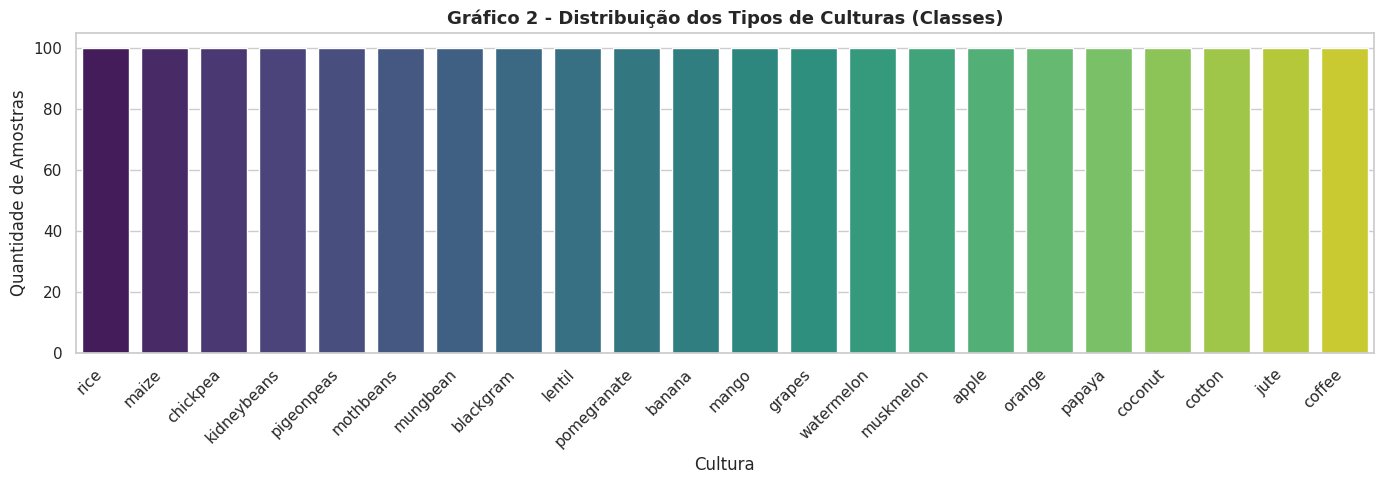


Total de classes (culturas) identificadas: 22
Classes presentes no dataset:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


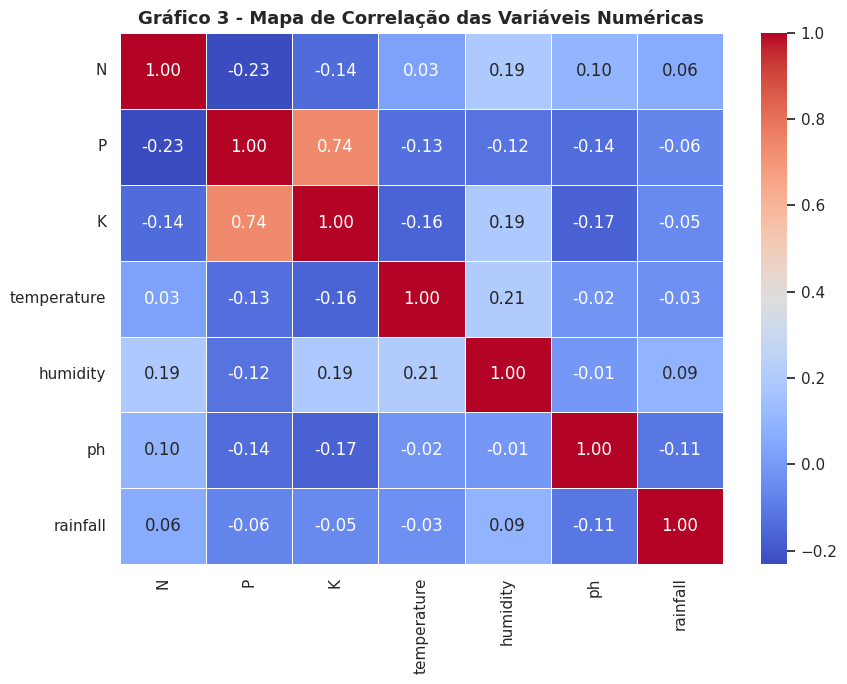


Principais correlações identificadas:
- Fósforo (P) e Potássio (K): apresentam uma correlação linear positiva moderada a forte (0.74). Este é o relacionamento mais significativo do gráfico, sugerindo tendência de crescimento conjunto entre essas variáveis nas amostras de solo.
- Nutrientes vs. Variáveis Climáticas: de forma geral, as variáveis de nutrientes (N, P, K) apresentam correlação linear fraca ou desprezível com os fatores climáticos (temperatura, umidade e chuva), com coeficientes muito próximos de zero. Vale ressaltar que a ausência de correlação linear não exclui a possibilidade de relações não lineares complexas entre esses fatores ecológicos.
- Variáveis climáticas: temperatura, umidade e pluviosidade (rainfall) apresentam correlações fracas entre si. A única associação sutil ocorre entre temperatura e umidade (0.21), enquanto as demais interações com a pluviosidade são praticamente nulas (0.09 com umidade e -0.03 com temperatura).
- Nitrogênio (N): embora mostre correlaç

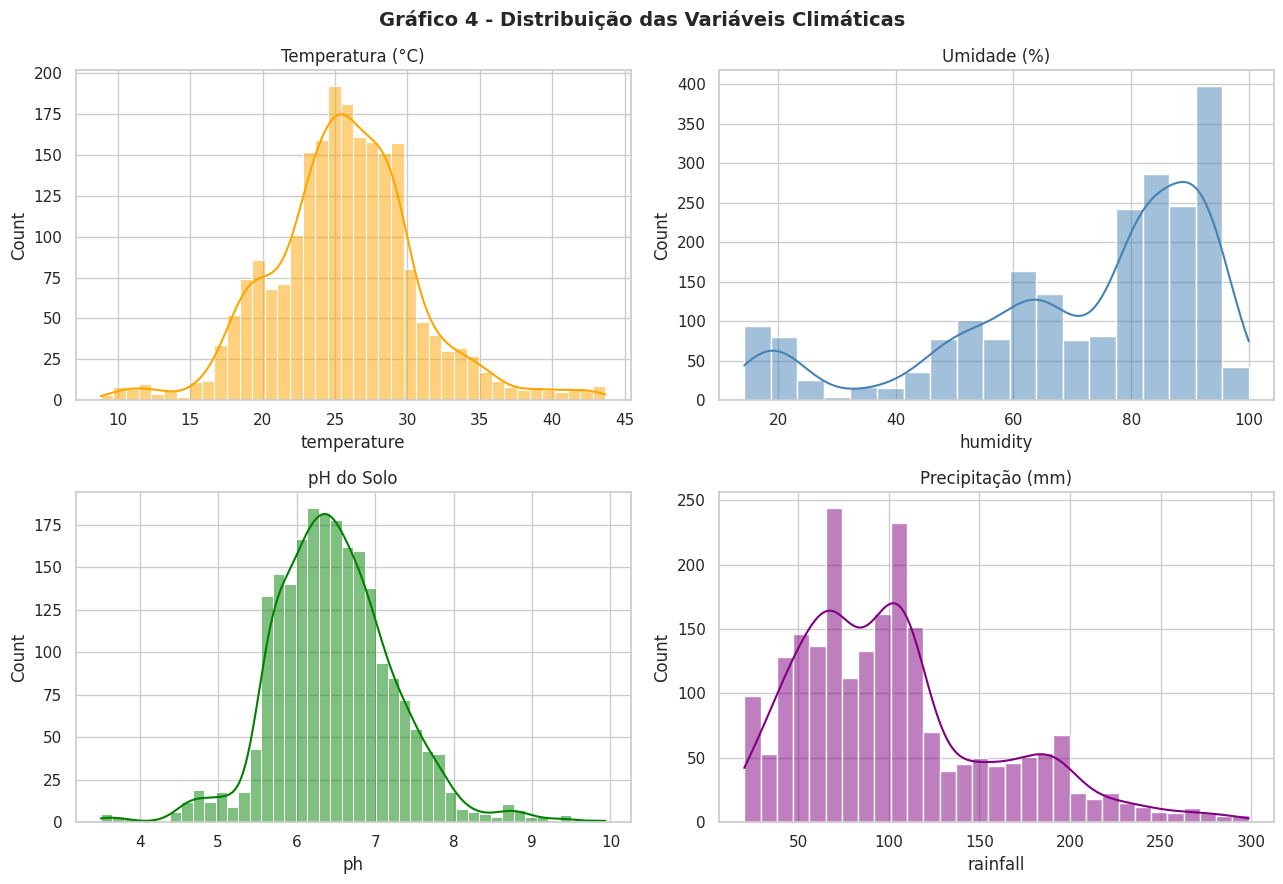


Insight do Gráfico 4:
- Temperatura: distribuição aproximadamente normal, concentrada entre 20°C e 30°C, indicando que a maioria das culturas do dataset prefere climas tropicais/subtropicais.
- Umidade: distribuição bimodal com picos em torno de 20% e 80%, sugerindo que o dataset contém culturas tanto de ambientes secos quanto úmidos.
- pH: distribuição bastante concentrada entre 5.5 e 7.5, faixa considerada adequada para a maioria das culturas agrícolas.
- Precipitação: distribuição com forte assimetria à direita, evidenciando que a maioria das culturas opera com baixa precipitação, mas algumas poucas (como arroz) demandam volumes muito elevados de chuva.



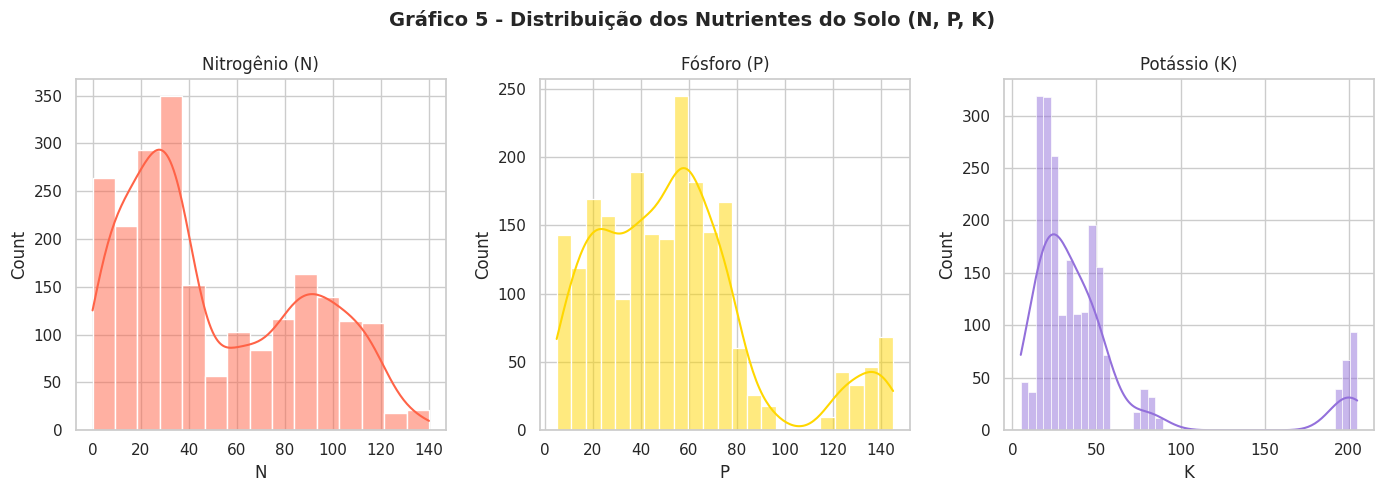


Insight do Gráfico 5:
- Nitrogênio (N): distribuição bastante dispersa, com culturas exigindo 
  desde valores muito baixos até acima de 100 kg/ha. Isso evidencia grande 
  variação na demanda nitrogenada entre as culturas do dataset.
- Fósforo (P): concentrado em dois grupos distintos — culturas de baixa 
  exigência (abaixo de 50) e culturas de alta exigência (acima de 100), 
  sugerindo perfis de solo bastante diferentes entre as espécies.
- Potássio (K): semelhante ao fósforo, com dois grupos claros. A maioria 
  das culturas opera com K baixo, mas algumas poucas (como uvas) apresentam 
  demandas extremamente elevadas — esses são os outliers vistos no boxplot.



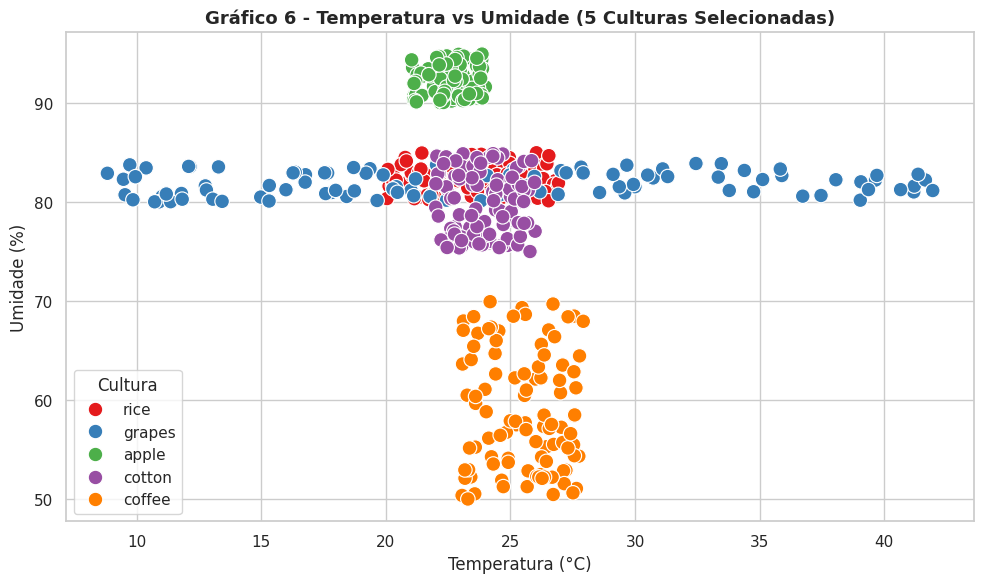


Insight do Gráfico 6:
- Arroz (rice): concentra-se em temperaturas moderadas (aprox. 20°C a 27°C), com umidade alta e constante, concentrada em torno de 80% a 85%.
- Café (coffee): apresenta grande variação na umidade (cerca de 50% a 70%), mantendo temperaturas moderadas a relativamente altas.
- Algodão (cotton): apresenta um agrupamento denso em temperaturas médias (22°C a 27°C) e umidade intermediária, variando entre 75% e 85%.
- Maçã (apple): é a cultura que exige os maiores níveis de umidade (acima de 90%), situando-se em uma faixa de temperatura muito específica e amena (21°C a 25°C).
- Uvas (grapes): apresenta a maior amplitude de temperatura observada no dataset, distribuindo-se por quase todo o eixo horizontal (de 8°C a 42°C), mas exigindo uma umidade estável próxima a 82%.
- Conclusão: as culturas apresentam agrupamentos relativamente distintos no espaço temperatura × umidade, especialmente maçã e café. Isso sugere que essas variáveis possuem bom potencial discriminativo para

/tmp/ipykernel_10739/4200869334.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='label', y='rainfall', palette='pastel')


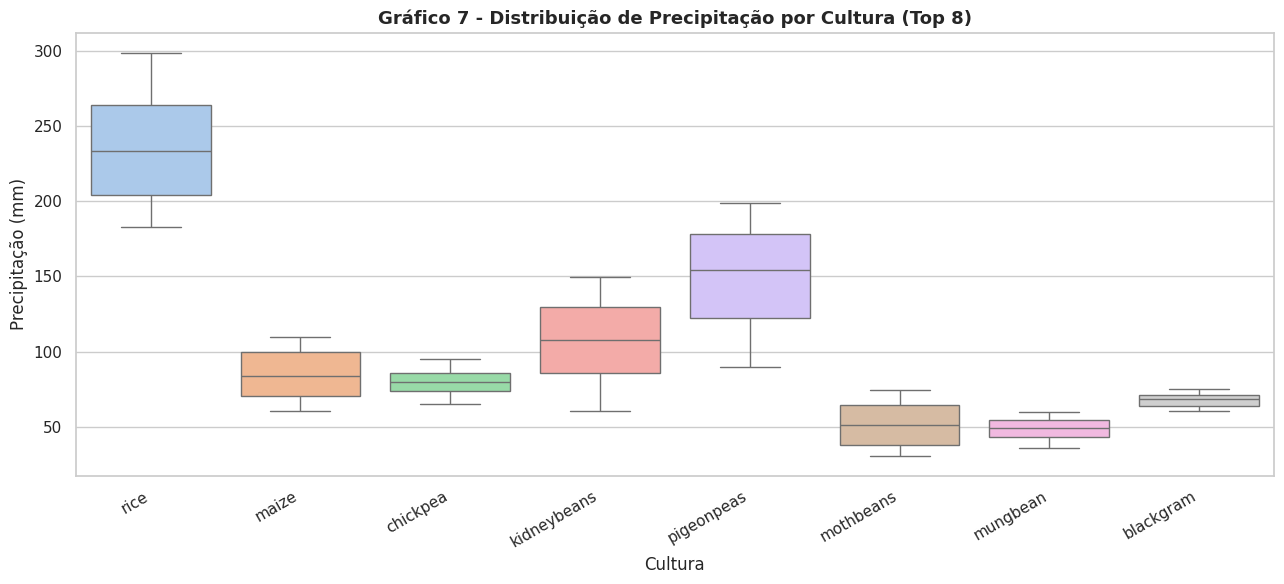


Insight do Gráfico 7:
- O arroz (rice) consolida-se como a cultura de maior demanda hídrica, com mediana superior a 230mm e valores máximos próximos de 300mm de precipitação.
- Pigeonpeas e kidneybeans apresentam necessidades hídricas intermediárias-altas. Pigeonpeas destaca-se com mediana em torno de 150mm, enquanto kidneybeans gira em torno de 110mm.
- Maize e chickpea apresentam distribuições mais equilibradas e moderadas de precipitação, concentrando-se majoritariamente entre 70mm e 100mm, indicando adaptação a cenários de chuva intermediária.
- Mothbeans e mungbean possuem os menores índices de precipitação do conjunto, com medianas e quartis concentrados majoritariamente abaixo de 60mm, o que indica alta tolerância a ambientes secos.
- Blackgram apresenta baixíssima variabilidade (caixa achatada) e precipitação moderadamente baixa, com distribuição estritamente concentrada entre 60mm e 75mm.
- Variabilidade: o gráfico evidencia diferenças significativas nas necessidades hídricas

In [67]:
# =============================================================================
# 4. ANÁLISE DESCRITIVA VISUAL
# =============================================================================
print("\n" + "=" * 60)
print("ANÁLISE DESCRITIVA VISUAL")
print("=" * 60)

# --- Gráfico 2: Distribuição das Classes (Tipos de Culturas) ---
plt.figure(figsize=(14, 5))
ordem = df['label'].value_counts().index
sns.countplot(data=df, x='label', palette='viridis', order=ordem)
plt.xticks(rotation=45, ha='right')
plt.title("Gráfico 2 - Distribuição dos Tipos de Culturas (Classes)",
          fontsize=13, fontweight='bold')
plt.xlabel("Cultura")
plt.ylabel("Quantidade de Amostras")
plt.tight_layout()
plt.show()

print(f"\nTotal de classes (culturas) identificadas: {df['label'].nunique()}")
print("Classes presentes no dataset:")
print(df['label'].value_counts())

# --- Gráfico 3: Mapa de Correlação entre Variáveis Numéricas ---
plt.figure(figsize=(9, 7))
corr_matrix = df.drop('label', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5)
plt.title("Gráfico 3 - Mapa de Correlação das Variáveis Numéricas",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPrincipais correlações identificadas:")

print("- Fósforo (P) e Potássio (K): apresentam uma correlação linear positiva "
      "moderada a forte (0.74). Este é o relacionamento mais significativo do "
      "gráfico, sugerindo tendência de crescimento conjunto "
      "entre essas variáveis nas amostras de solo.")

print("- Nutrientes vs. Variáveis Climáticas: de forma geral, "
      "as variáveis de nutrientes (N, P, K) apresentam "
      "correlação linear fraca ou desprezível com os fatores "
      "climáticos (temperatura, umidade e chuva), com "
      "coeficientes muito próximos de zero. Vale ressaltar "
      "que a ausência de correlação linear não exclui a "
      "possibilidade de relações não lineares complexas "
      "entre esses fatores ecológicos.")

print("- Variáveis climáticas: temperatura, umidade "
      "e pluviosidade (rainfall) apresentam correlações fracas entre si. "
      "A única associação sutil ocorre entre temperatura e umidade (0.21), "
      "enquanto as demais interações com a pluviosidade "
      "são praticamente nulas (0.09 com umidade e -0.03 com temperatura).")

print("- Nitrogênio (N): embora mostre correlações negativas fracas "
      "com o Fósforo (-0.23) e Potássio (-0.14), o Nitrogênio não está "
      "completamente isolado. Ele apresenta associações "
      "positivas fracas com a umidade (0.19) e com o "
      "pH (0.10), sugerindo interações sutis que merecem "
      "atenção na análise agronômica.")

print("- Dinâmica do pH do Solo: o pH atua de forma independente das variáveis "
      "climáticas, mas exibe pequenas correlações negativas com o "
      "Potássio (-0.17) e Fósforo (-0.14), o que "
      "pode estar associado à dinâmica de solubilidade "
      "e fixação de nutrientes em diferentes níveis de acidez do solo.")

print("- Apesar das correlações serem fracas, Nitrogênio (N) "
      "e Potássio (K) apresentam leve tendência positiva "
      "com a umidade, sugerindo possível influência de "
      "ambientes mais úmidos em determinadas culturas.")

print("- Conclusão para Modelagem (Machine Learning): de forma geral, "
      "as variáveis apresentam pouca redundância entre si, o que pode ajudar os "
      "modelos de machine learning a terem um "
      "comportamento mais estável e eficiente, reduzindo o risco de overfitting.\n")

# --- Gráfico 4: Histogramas das Variáveis Climáticas ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Gráfico 4 - Distribuição das Variáveis Climáticas",
             fontsize=14, fontweight='bold')

sns.histplot(df['temperature'], kde=True, ax=axes[0, 0],
             color='orange').set_title('Temperatura (°C)')
sns.histplot(df['humidity'], kde=True, ax=axes[0, 1],
             color='steelblue').set_title('Umidade (%)')
sns.histplot(df['ph'], kde=True, ax=axes[1, 0],
             color='green').set_title('pH do Solo')
sns.histplot(df['rainfall'], kde=True, ax=axes[1, 1],
             color='purple').set_title('Precipitação (mm)')

plt.tight_layout()
plt.show()

print("\nInsight do Gráfico 4:")

print("- Temperatura: distribuição aproximadamente normal, "
    "concentrada entre 20°C e 30°C, indicando que a "
    "maioria das culturas do dataset prefere climas tropicais/subtropicais.")

print("- Umidade: distribuição bimodal com picos em torno "
    "de 20% e 80%, sugerindo que o dataset contém "
    "culturas tanto de ambientes secos quanto úmidos.")

print("- pH: distribuição bastante concentrada entre "
    "5.5 e 7.5, faixa considerada adequada para a maioria das culturas agrícolas.")

print("- Precipitação: distribuição com forte assimetria "
    "à direita, evidenciando que a maioria das culturas "
    "opera com baixa precipitação, mas algumas poucas "
    "(como arroz) demandam volumes muito elevados de chuva.\n")

# --- Gráfico 5: Histogramas das Variáveis de Solo (N, P, K) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Gráfico 5 - Distribuição dos Nutrientes do Solo (N, P, K)",
             fontsize=14, fontweight='bold')

sns.histplot(df['N'], kde=True, ax=axes[0],
             color='tomato').set_title('Nitrogênio (N)')
sns.histplot(df['P'], kde=True, ax=axes[1],
             color='gold').set_title('Fósforo (P)')
sns.histplot(df['K'], kde=True, ax=axes[2],
             color='mediumpurple').set_title('Potássio (K)')

plt.tight_layout()
plt.show()

print("\nInsight do Gráfico 5:")

print("- Nitrogênio (N): distribuição bastante dispersa, com culturas exigindo ")

print("  desde valores muito baixos até acima de 100 kg/ha. Isso evidencia grande ")

print("  variação na demanda nitrogenada entre as culturas do dataset.")

print("- Fósforo (P): concentrado em dois grupos distintos — culturas de baixa ")

print("  exigência (abaixo de 50) e culturas de alta exigência (acima de 100), ")

print("  sugerindo perfis de solo bastante diferentes entre as espécies.")

print("- Potássio (K): semelhante ao fósforo, com dois grupos claros. A maioria ")

print("  das culturas opera com K baixo, mas algumas poucas (como uvas) apresentam ")

print("  demandas extremamente elevadas — esses são os outliers vistos no boxplot.\n")

# --- Gráfico 6: Scatter Plot — Temperatura vs Umidade (5 culturas) ---
culturas_amostra = ['rice', 'coffee', 'cotton', 'apple', 'grapes']
df_subset = df[df['label'].isin(culturas_amostra)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_subset, x='temperature', y='humidity',
                hue='label', s=110, palette='Set1')
plt.title("Gráfico 6 - Temperatura vs Umidade (5 Culturas Selecionadas)",
          fontsize=13, fontweight='bold')
plt.xlabel("Temperatura (°C)")
plt.ylabel("Umidade (%)")
plt.legend(title="Cultura")
plt.tight_layout()
plt.show()

print("\nInsight do Gráfico 6:")

print("- Arroz (rice): concentra-se em temperaturas moderadas "
    "(aprox. 20°C a 27°C), com umidade alta e constante, "
    "concentrada em torno de 80% a 85%.")

print("- Café (coffee): apresenta grande variação na umidade "
    "(cerca de 50% a 70%), mantendo temperaturas moderadas "
    "a relativamente altas.")

print("- Algodão (cotton): apresenta um agrupamento denso "
    "em temperaturas médias (22°C a 27°C) e umidade "
    "intermediária, variando entre 75% e 85%.")

print("- Maçã (apple): é a cultura que exige os maiores níveis "
    "de umidade (acima de 90%), situando-se em uma faixa "
    "de temperatura muito específica e amena (21°C a 25°C).")

print("- Uvas (grapes): apresenta a maior amplitude de "
    "temperatura observada no dataset, distribuindo-se "
    "por quase todo o eixo horizontal (de 8°C a 42°C), "
    "mas exigindo uma umidade estável próxima a 82%.")

print("- Conclusão: as culturas apresentam agrupamentos "
    "relativamente distintos no espaço temperatura × "
    "umidade, especialmente maçã e café. Isso sugere "
    "que essas variáveis possuem bom potencial "
    "discriminativo para modelos de classificação "
    "e previsão agrícola.\n")

# --- Gráfico 7: Boxplot de Rainfall por Cultura (top 8 culturas) ---
top_culturas = df['label'].value_counts().nlargest(8).index
df_top = df[df['label'].isin(top_culturas)]

plt.figure(figsize=(13, 6))
sns.boxplot(data=df_top, x='label', y='rainfall', palette='pastel')
plt.title("Gráfico 7 - Distribuição de Precipitação por Cultura (Top 8)",
          fontsize=13, fontweight='bold')
plt.xlabel("Cultura")
plt.ylabel("Precipitação (mm)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\nInsight do Gráfico 7:")

print("- O arroz (rice) consolida-se como a cultura de maior demanda hídrica, "
    "com mediana superior a 230mm e valores máximos próximos de 300mm "
    "de precipitação.")

print("- Pigeonpeas e kidneybeans apresentam necessidades hídricas "
    "intermediárias-altas. Pigeonpeas destaca-se com mediana em torno "
    "de 150mm, enquanto kidneybeans gira em torno de 110mm.")

print("- Maize e chickpea apresentam distribuições mais equilibradas "
    "e moderadas de precipitação, concentrando-se majoritariamente "
    "entre 70mm e 100mm, indicando adaptação a cenários de chuva "
    "intermediária.")

print("- Mothbeans e mungbean possuem os menores índices de precipitação "
    "do conjunto, com medianas e quartis concentrados majoritariamente "
    "abaixo de 60mm, o que indica alta tolerância a ambientes secos.")

print("- Blackgram apresenta baixíssima variabilidade (caixa achatada) "
    "e precipitação moderadamente baixa, com distribuição estritamente "
    "concentrada entre 60mm e 75mm.")

print("- Variabilidade: o gráfico evidencia diferenças significativas "
    "nas necessidades hídricas entre as culturas. Enquanto o arroz "
    "demanda altos volumes de chuva, culturas como mungbean e "
    "mothbeans adaptam-se melhor a regiões de baixa precipitação, "
    "reforçando a relevância da variável 'rainfall' na diferenciação "
    "entre culturas agrícolas.\n")

# 5. Análise do Perfil Ideal de Solo e Clima

Definimos o **Perfil Ideal Base** como a **média global** de todas as condições
do dataset. Ele representa um "ponto de equilíbrio" médio entre todas as culturas.

Selecionamos três culturas com características contrastantes:
- **Arroz (rice):** cultura de alta demanda hídrica
- **Algodão (cotton):** cultura com alto consumo de Nitrogênio
- **Café (coffee):** cultura com exigências nutricionais específicas

A comparação revelará como cada produto se afasta — ou se aproxima — do
perfil médio global em cada variável.


ANÁLISE DO PERFIL IDEAL


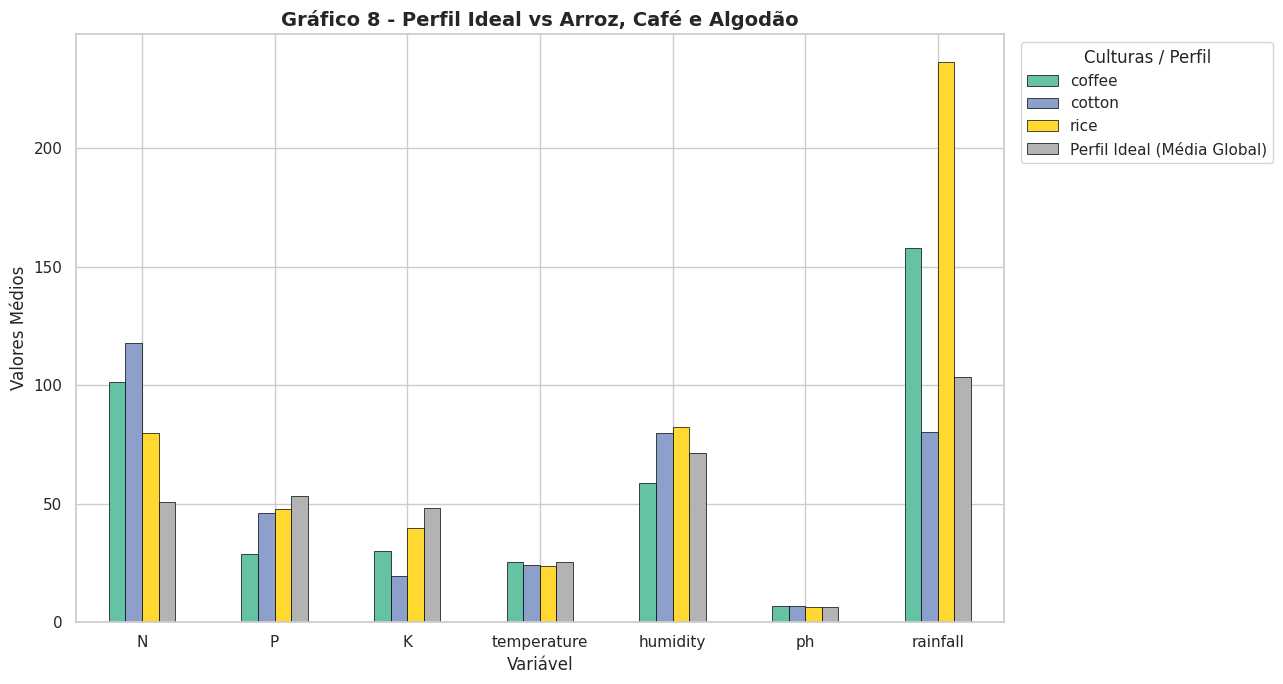


--- Tabela Comparativa: Médias por Cultura vs Perfil Ideal ---
label        coffee  cotton    rice  Perfil Ideal (Média Global)
N            101.20  117.77   79.89                        50.55
P             28.74   46.24   47.58                        53.36
K             29.94   19.56   39.87                        48.15
temperature   25.54   23.99   23.69                        25.62
humidity      58.87   79.84   82.27                        71.48
ph             6.79    6.91    6.43                         6.47
rainfall     158.07   80.40  236.18                       103.46

=== CONCLUSÕES DO PERFIL IDEAL ===

1. ARROZ (rice):
   - É a cultura que mais se afasta do perfil climático ideal em precipitação.
   - Exige volume de chuvas muito acima da média global (mais que o dobro).
   - A umidade também tende a ser superior à média.
   - Enquanto o Nitrogênio (N) apresenta valores acima do perfil global,
     os níveis de Fósforo (P) e Potássio (K) permanecem ligeiramente abaixo
     d

In [68]:
# =============================================================================
# 5. ANÁLISE DO PERFIL IDEAL DE SOLO/CLIMA
# =============================================================================
print("\n" + "=" * 60)
print("ANÁLISE DO PERFIL IDEAL")
print("=" * 60)

# Calculando o Perfil Ideal (Média Global)
perfil_ideal = df.drop('label', axis=1).mean()

# Médias das 3 culturas escolhidas
culturas_escolhidas = ['rice', 'coffee', 'cotton']
medias_culturas = df[df['label'].isin(culturas_escolhidas)].groupby('label').mean()

# DataFrame para o gráfico
df_comparacao = medias_culturas.T
df_comparacao['Perfil Ideal (Média Global)'] = perfil_ideal

# --- Gráfico 8: Comparação Perfil Ideal vs Culturas ---
df_comparacao.plot(kind='bar', figsize=(13, 7), colormap='Set2',
                   edgecolor='black', linewidth=0.5)
plt.title("Gráfico 8 - Perfil Ideal vs Arroz, Café e Algodão",
          fontsize=14, fontweight='bold')
plt.ylabel("Valores Médios")
plt.xlabel("Variável")
plt.xticks(rotation=0)
plt.legend(title='Culturas / Perfil', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Tabela Comparativa: Médias por Cultura vs Perfil Ideal ---")
print(df_comparacao.round(2).to_string())

print("""
=== CONCLUSÕES DO PERFIL IDEAL ===

1. ARROZ (rice):
   - É a cultura que mais se afasta do perfil climático ideal em precipitação.
   - Exige volume de chuvas muito acima da média global (mais que o dobro).
   - A umidade também tende a ser superior à média.
   - Enquanto o Nitrogênio (N) apresenta valores acima do perfil global,
     os níveis de Fósforo (P) e Potássio (K) permanecem ligeiramente abaixo
     da média.
   - Conclusão: o arroz é fortemente dependente de água e Nitrogênio,
     mas não é a cultura mais exigente nos outros nutrientes do solo.

2. ALGODÃO (cotton):
   - Apresenta o maior consumo de Nitrogênio (N) dentre as três culturas,
     ultrapassando o dobro da média global.
   - Possui a menor exigência de Potássio (K) entre as culturas analisadas,
     mantendo valores muito abaixo da média global.
   - Apesar de exigir menor volume de chuva que culturas como arroz e café,
     apresenta umidade média acima do perfil global.
   - Conclusão: o algodão combina alta exigência de Nitrogênio com baixa
     necessidade de Potássio, demonstrando adaptação eficiente a cenários
     de precipitação moderada.

3. CAFÉ (coffee):
   - Possui necessidades hídricas elevadas, com precipitação acima da
     média global.
   - Apesar do alto índice de chuva, apresenta umidade atmosférica abaixo
     do perfil médio do conjunto.
   - Alta exigência de Nitrogênio (N), porém inferior à do algodão.
   - Fósforo (P) e Potássio (K) permanecem abaixo da média global.
   - Conclusão: o café combina elevada demanda hídrica com forte exigência
     de Nitrogênio, mantendo baixos níveis de P e K em seu perfil nutricional.

CONCLUSÃO GERAL: A média global serve como ponto de referência para
comparar os diferentes perfis agrícolas, mas não representa uma condição
ideal universal. As culturas analisadas apresentaram diferenças significativas
principalmente em precipitação, umidade e composição nutricional do solo.

Apesar dessas variações, observou-se que temperatura e pH permaneceram
relativamente próximos entre as culturas, sugerindo faixas climáticas e químicas
mais estáveis para o desenvolvimento agrícola no dataset analisado.

Entre os nutrientes, o Nitrogênio (N) destacou-se como o elemento com maior
tendência de demanda elevada entre as culturas estudadas, enquanto Fósforo (P)
e Potássio (K) apresentaram maior variação conforme o tipo de cultivo.

Conclusão final: não existe uma combinação universal de solo e clima capaz
de atender simultaneamente todas as culturas agrícolas, já que cada uma
possui necessidades específicas de água, nutrientes e condições ambientais.

Dessa forma, torna-se essencial compreender individualmente o perfil de cada
cultura e do solo em que será cultivada, permitindo o desenvolvimento de
soluções tecnológicas mais eficientes, sustentáveis e inteligentes para o
agronegócio.

Nesse contexto, técnicas de análise de dados, automação e Inteligência
Artificial tornam-se ferramentas fundamentais para apoiar decisões agrícolas,
otimizar recursos e adaptar sistemas de irrigação e monitoramento às
necessidades reais de cada plantação.
""")

# 6. Separação dos Dados: Treino, Validação e Teste

Seguindo as boas práticas de Machine Learning apresentadas no capítulo,
dividimos os dados em **três conjuntos** independentes:

| Conjunto    | Proporção | Finalidade                                      |
|-------------|-----------|--------------------------------------------------|
| Treino      | 60%       | Aprendizado dos padrões pelos algoritmos         |
| Validação   | 20%       | Comparação dos 5 modelos e seleção do campeão    |
| Teste       | 20%       | Avaliação final do modelo campeão (dados inéditos)|

**Por que três conjuntos?**
Usar o conjunto de teste para escolher o melhor modelo contamina a avaliação
final. O conjunto de validação serve exatamente para fazer essa escolha,
reservando o teste para um relatório honesto da performance real.

**Normalização:** aplicamos o MinMaxScaler com fit APENAS no treino,
evitando data leakage (vazamento de dados) para validação e teste.

In [69]:
# =============================================================================
# 6. SEPARAÇÃO DOS DADOS: TREINO, VALIDAÇÃO E TESTE
# =============================================================================
print("\n" + "=" * 60)
print("SEPARAÇÃO DOS DADOS E PRÉ-PROCESSAMENTO")
print("=" * 60)

# 1. Separando features (X) e target (y)
X = df.drop('label', axis=1)
y = df['label']

# 2. Codificando a variável alvo com LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nClasses identificadas pelo LabelEncoder:")
for i, classe in enumerate(le.classes_):
    print(f"  {i} -> {classe}")

# 3. Divisão inicial: Treino+Validação (80%) e Teste (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded   # garante proporção das classes em cada split
)

# 4. Divisão secundária: Treino (60%) e Validação (20%)
# X_temp = 80% do total; retirar 25% dele = 20% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

# 5. Normalização com MinMaxScaler (fit SOMENTE no treino)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)   # aprende + transforma
X_val_scaled   = scaler.transform(X_val)          # só transforma
X_test_scaled  = scaler.transform(X_test)         # só transforma

print(f"\n{'Conjunto':<20} {'Amostras':>10} {'% do Total':>12}")
print("-" * 44)
print(f"{'Treino':<20} {X_train.shape[0]:>10} {X_train.shape[0]/len(df)*100:>11.1f}%")
print(f"{'Validação':<20} {X_val.shape[0]:>10} {X_val.shape[0]/len(df)*100:>11.1f}%")
print(f"{'Teste':<20} {X_test.shape[0]:>10} {X_test.shape[0]/len(df)*100:>11.1f}%")
print(f"{'Total':<20} {len(df):>10} {'100.0%':>12}")


SEPARAÇÃO DOS DADOS E PRÉ-PROCESSAMENTO

Classes identificadas pelo LabelEncoder:
  0 -> apple
  1 -> banana
  2 -> blackgram
  3 -> chickpea
  4 -> coconut
  5 -> coffee
  6 -> cotton
  7 -> grapes
  8 -> jute
  9 -> kidneybeans
  10 -> lentil
  11 -> maize
  12 -> mango
  13 -> mothbeans
  14 -> mungbean
  15 -> muskmelon
  16 -> orange
  17 -> papaya
  18 -> pigeonpeas
  19 -> pomegranate
  20 -> rice
  21 -> watermelon

Conjunto               Amostras   % do Total
--------------------------------------------
Treino                     1320        60.0%
Validação                   440        20.0%
Teste                       440        20.0%
Total                      2200       100.0%


# 7. Treinamento e Comparação dos 5 Modelos (Conjunto de Validação)

Treinamos 5 algoritmos diferentes com os dados de Treino e avaliamos a
performance de cada um no conjunto de Validação.

Os algoritmos escolhidos cobrem diferentes abordagens:
- **KNN:** baseado em distância entre vizinhos
- **Regressão Logística:** separação linear probabilística
- **Árvore de Decisão:** regras sequenciais de divisão
- **Random Forest:** conjunto de múltiplas árvores (ensemble)
- **SVM:** maximização de margem entre classes

O modelo com maior acurácia na validação foi selecionado como campeão
e foi sua performance final avaliada no conjunto de Teste.


TREINAMENTO DOS 5 MODELOS

--- Performance na base de VALIDAÇÃO ---

  KNN (K=5)                     : 96.59%
  Regressão Logística           : 92.50%
  Árvore de Decisão             : 98.18%
  Random Forest                 : 99.09%
  SVM (RBF)                     : 97.27%

🏆 Modelo Campeão na Validação: Random Forest
   Acurácia na Validação: 99.09%


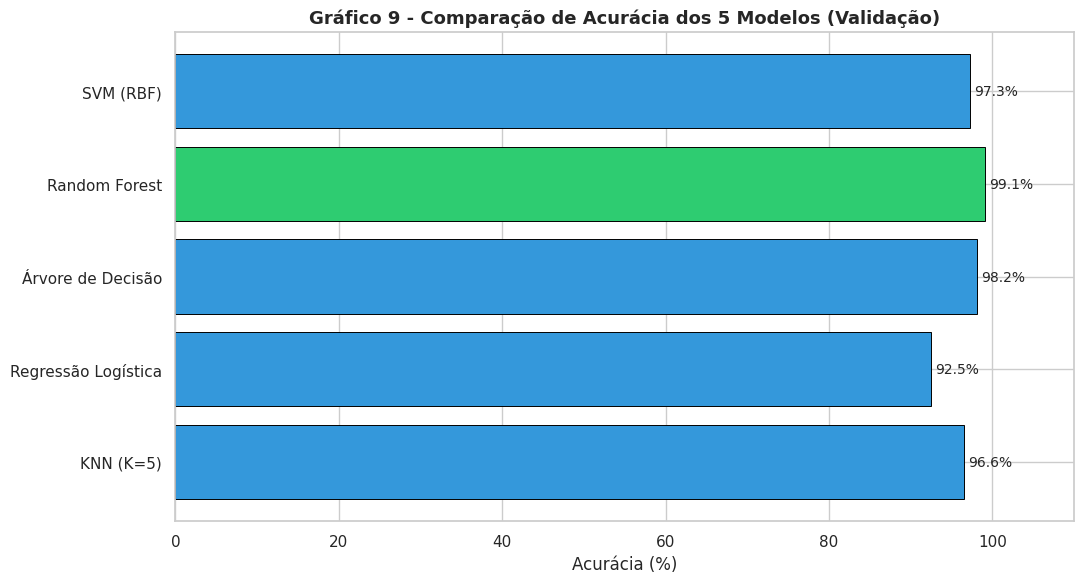

In [70]:
# =============================================================================
# 7. TREINAMENTO DOS 5 MODELOS E AVALIAÇÃO NA VALIDAÇÃO
# =============================================================================
print("\n" + "=" * 60)
print("TREINAMENTO DOS 5 MODELOS")
print("=" * 60)

# Definição dos 5 modelos
modelos = {
    "KNN (K=5)":                 KNeighborsClassifier(n_neighbors=5),
    "Regressão Logística":       LogisticRegression(max_iter=2000, random_state=42),
    "Árvore de Decisão":         DecisionTreeClassifier(random_state=42),
    "Random Forest":             RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":                 SVC(kernel='rbf', random_state=42),
}

print("\n--- Performance na base de VALIDAÇÃO ---\n")
resultados_val = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred_val = modelo.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred_val)
    resultados_val[nome] = acc
    print(f"  {nome:<30}: {acc * 100:.2f}%")

# Identificando o modelo campeão
melhor_nome = max(resultados_val, key=resultados_val.get)
melhor_modelo = modelos[melhor_nome]
melhor_acc_val = resultados_val[melhor_nome]

print(f"\n🏆 Modelo Campeão na Validação: {melhor_nome}")
print(f"   Acurácia na Validação: {melhor_acc_val * 100:.2f}%")

# --- Gráfico 9: Comparação de Acurácia dos Modelos na Validação ---
plt.figure(figsize=(11, 6))
nomes = list(resultados_val.keys())
acuracias = [v * 100 for v in resultados_val.values()]
cores = ['#2ecc71' if n == melhor_nome else '#3498db' for n in nomes]

bars = plt.barh(nomes, acuracias, color=cores, edgecolor='black', linewidth=0.7)
plt.xlabel("Acurácia (%)")
plt.title("Gráfico 9 - Comparação de Acurácia dos 5 Modelos (Validação)",
          fontsize=13, fontweight='bold')
plt.xlim(0, 110)

for bar, acc in zip(bars, acuracias):
    plt.text(acc + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{acc:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 8. Avaliação Final do Modelo Campeão no Conjunto de Teste

O modelo com maior acurácia na validação foi selecionado para avaliação final no conjunto de teste.

Esta é a métrica que reportamos como resultado final do projeto, pois reflete
o desempenho real esperado em produção.

Também geramos a Matriz de Confusão Multiclasse, que nos permite visualizar:
- **Diagonal principal (azul intenso):** acertos do modelo
- **Fora da diagonal:** erros — onde o modelo confundiu culturas


AVALIAÇÃO FINAL NO TESTE — Modelo: Random Forest

Acurácia Final no TESTE: 99.77%
(Acurácia na Validação era: 99.09%)

--- Relatório de Classificação Completo ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      1.00      1.00        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00  

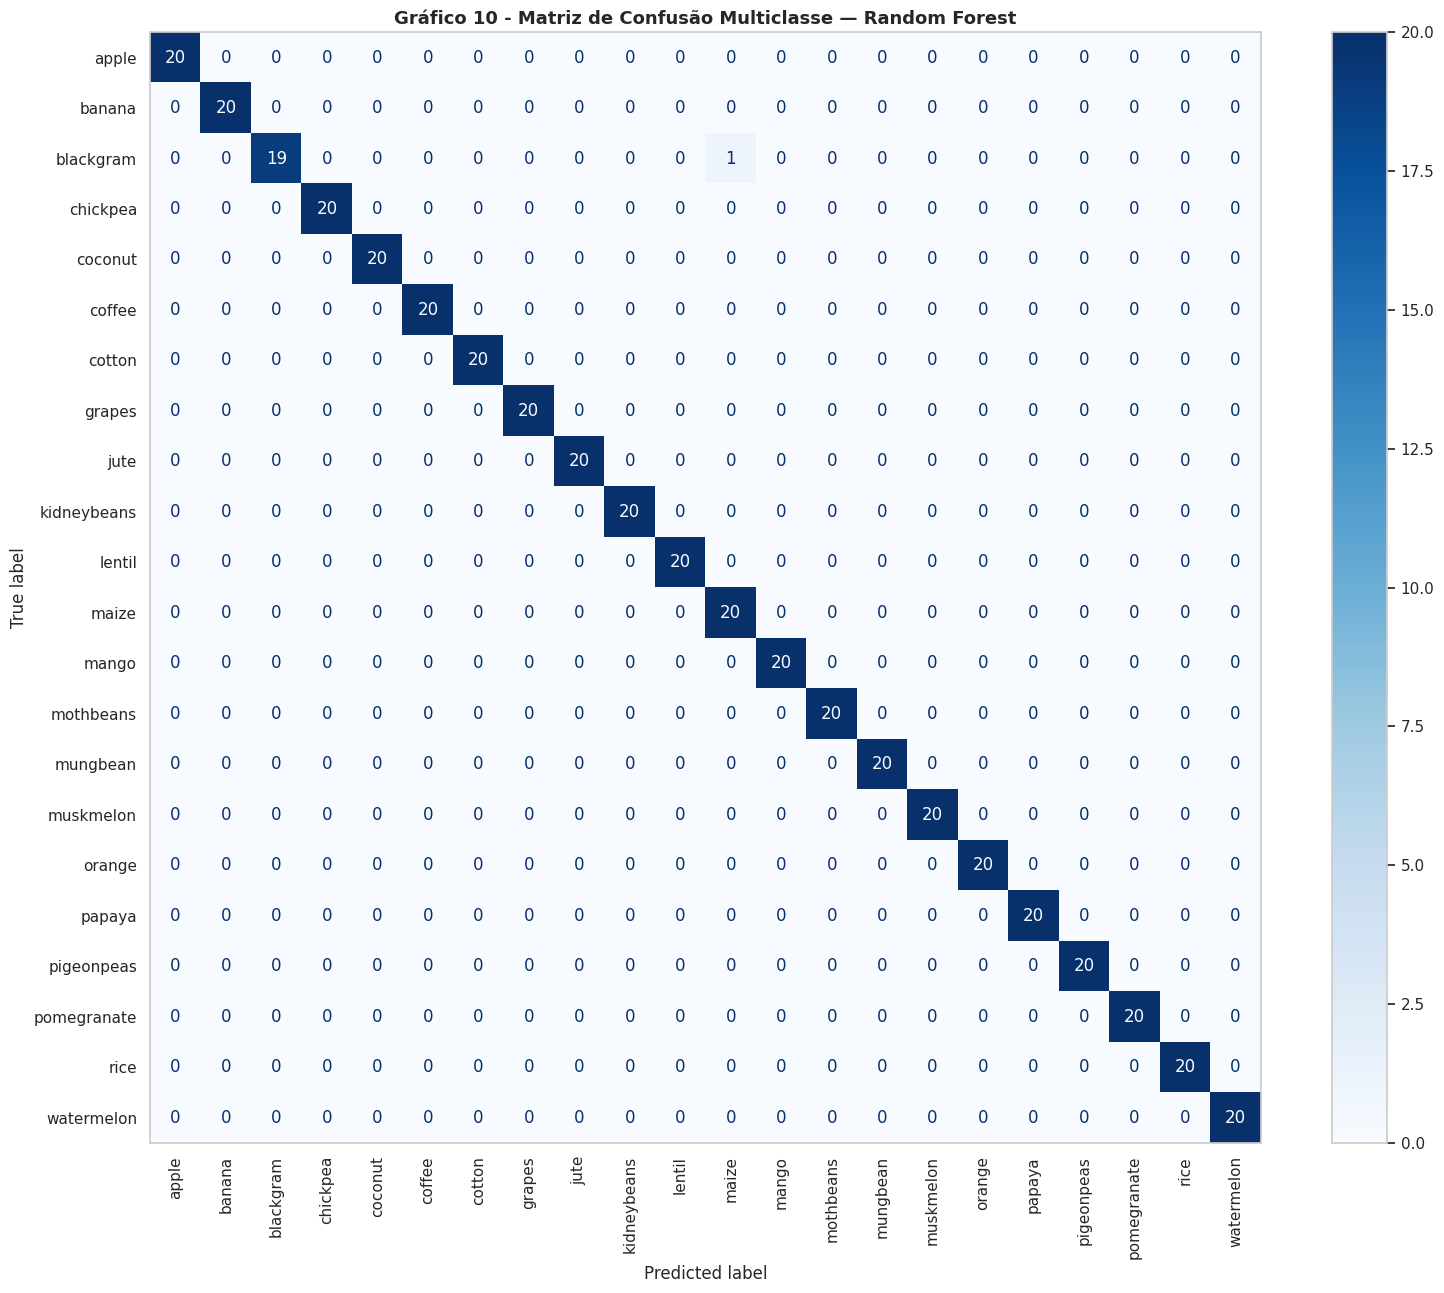

In [71]:
# =============================================================================
# 8. AVALIAÇÃO FINAL DO MODELO CAMPEÃO NO TESTE
# =============================================================================
print("\n" + "=" * 60)
print(f"AVALIAÇÃO FINAL NO TESTE — Modelo: {melhor_nome}")
print("=" * 60)

y_pred_test = melhor_modelo.predict(X_test_scaled)
acc_teste = accuracy_score(y_test, y_pred_test)

print(f"\nAcurácia Final no TESTE: {acc_teste * 100:.2f}%")
print(f"(Acurácia na Validação era: {melhor_acc_val * 100:.2f}%)\n")

# Convertendo rótulos numéricos de volta para nomes
y_test_nomes = le.inverse_transform(y_test)
y_pred_nomes = le.inverse_transform(y_pred_test)

print("--- Relatório de Classificação Completo ---")
print(classification_report(y_test_nomes, y_pred_nomes))

# --- Gráfico 10: Matriz de Confusão Multiclasse ---
cm = confusion_matrix(y_test_nomes, y_pred_nomes, labels=le.classes_)

plt.figure(figsize=(16, 13))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical', ax=plt.gca())
plt.title(f"Gráfico 10 - Matriz de Confusão Multiclasse — {melhor_nome}",
          fontsize=13, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

# 9. Conclusões Finais do Projeto

In [72]:
### Metodologia e Boas Práticas

"""**Separação do data set entre Treino / Validação / Teste:**
A estratégia de três conjuntos ajudou a reduzir o risco de overfitting
e permitiu uma avaliação mais confiável do modelo. O conjunto de teste foi usado
somente ao final, reportando a performance real em dados completamente inéditos.

**Decisão Biológica sobre Outliers:**
Preservar os outliers foi uma decisão acertada — variáveis extremas funcionaram
como "assinatura nutricional" de culturas específicas, sendo informação valiosa
para os algoritmos, não ruído a ser eliminado.

**Feature Engineering:**
O LabelEncoder e o MinMaxScaler foram aplicados. O scaler
foi treinado (fit) exclusivamente nos dados de treino, sem qualquer contato
com validação ou teste, evitando data leakage.

### Performance dos Modelos

Todos os modelos foram treinados sob as mesmas condições e avaliados
no mesmo conjunto de validação, garantindo comparação justa.

**Pontos Fortes do Projeto:**
- Alta acurácia obtida pelos melhores modelos (>90%), evidenciando forte
  capacidade preditiva das variáveis de solo e clima na identificação da cultura
  adequada.
- A Matriz de Confusão confirma: a grande maioria das predições cai na
  diagonal principal (verdadeiros positivos), provando que o modelo
  raramente confunde uma cultura com outra.
- A análise do Perfil Ideal demonstrou, com dados e gráficos, que cada
  cultura possui uma "impressão digital" única de exigências agronômicas.

**Limitações e Possíveis Melhorias:**
- O dataset, embora rico em culturas, poderia ser maior para tornar os
  conjuntos de validação e teste mais representativos.
- Uma busca de hiperparâmetros (GridSearchCV) poderia refinar ainda mais
  os modelos, especialmente KNN (valor de K) e SVM (C e gamma).
- Métricas complementares como F1-Score macro e a Curva ROC (em abordagem
  OvR) agregariam uma visão mais completa em cenários com classes
  desbalanceadas.
"""

print("\n" + "=" * 60)
print("SUMÁRIO FINAL DOS RESULTADOS")
print("=" * 60)
print(f"\n{'Modelo':<30} {'Acurácia Validação':>20}")
print("-" * 52)
for nome, acc in sorted(resultados_val.items(), key=lambda x: x[1], reverse=True):
    destaque = " ← CAMPEÃO" if nome == melhor_nome else ""
    print(f"{nome:<30} {acc*100:>19.2f}%{destaque}")

print(f"\n{'Acurácia Final no Teste':<30} {acc_teste*100:>19.2f}%")
print(f"{'Modelo Selecionado':<30} {melhor_nome:>20}")


SUMÁRIO FINAL DOS RESULTADOS

Modelo                           Acurácia Validação
----------------------------------------------------
Random Forest                                99.09% ← CAMPEÃO
Árvore de Decisão                            98.18%
SVM (RBF)                                    97.27%
KNN (K=5)                                    96.59%
Regressão Logística                          92.50%

Acurácia Final no Teste                      99.77%
Modelo Selecionado                    Random Forest
